# Alzheimer's Disease Brain MRI Segmentation
## VGG16 + UNet | OASIS Dataset
Full pipeline: data loading → preprocessing → model training → metrics → visualizations

## 1. Import Libraries

In [1]:
import os

def print_tree(path, max_depth=5):
    for root, dirs, files in os.walk(path):
        level = root.replace(path, '').count(os.sep)
        if level > max_depth:
            break
        indent = '  ' * level
        print(f'{indent}{os.path.basename(root)}/')
        if level < max_depth:
            for f in files[:2]:
                print(f'{indent}  {f}')

print_tree('/kaggle/input/datasets')

datasets/
  maheswarimudadla/
    oasis-disc1/
      disc1/
        OAS1_0023_MR1/
          OAS1_0023_MR1.xml
          OAS1_0023_MR1.txt
          PROCESSED/


In [2]:
import os
import cv2
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, UpSampling2D,
    concatenate, BatchNormalization, Dropout, Activation
)
from tensorflow.keras.models import Model
from tensorflow.keras.applications import VGG16
from tensorflow.keras import callbacks
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
import time
import datetime

print('TensorFlow version:', tf.__version__)
print('GPUs available:', tf.config.list_physical_devices('GPU'))

2026-06-12 08:23:07.841475: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781252587.865204     679 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781252587.873177     679 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781252587.892744     679 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781252587.892769     679 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781252587.892772     679 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Configuration

In [3]:
# ─── Paths ────────────────────────────────────────────────────────────────────
# OASIS disc1 unzipped structure:
#   /kaggle/input/<your-dataset-name>/disc1/OAS1_XXXX_MR1/
#       processed/
#           ├── mpr-1/
#           │   ├── anon.img
#           │   └── anon.hdr
#           └── T88_111/
#               └── OAS1_XXXX_MR1_mpr_n4_anon_111_t88_masked_gfc_fseg.img  ← seg mask
#
# Adjust OASIS_ROOT to wherever your dataset lives in Kaggle input

OASIS_ROOT = '/kaggle/input/datasets/maheswarimudadla/oasis-disc1/disc1'
PROCESSED_DIR   = 'oasis_processed'
IMAGE_FOLDER    = os.path.join(PROCESSED_DIR, 'images')
MASK_FOLDER     = os.path.join(PROCESSED_DIR, 'masks')
TRAIN_IMG_DIR   = os.path.join(PROCESSED_DIR, 'train', 'images')
TRAIN_MASK_DIR  = os.path.join(PROCESSED_DIR, 'train', 'masks')
TEST_IMG_DIR    = os.path.join(PROCESSED_DIR, 'test',  'images')
TEST_MASK_DIR   = os.path.join(PROCESSED_DIR, 'test',  'masks')

# ─── Hyperparameters ──────────────────────────────────────────────────────────
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 16
EPOCHS      = 50
SEED        = 42
TEST_SPLIT  = 0.15

print('Config set ✓')

Config set ✓


## 3. Load & Preprocess OASIS Data
OASIS stores brain volumes as Analyze `.img/.hdr` pairs. We slice along the axial axis and save each 2-D slice as a PNG.

In [4]:
# Install nibabel to read Analyze / NIfTI files
!pip install nibabel -q
import nibabel as nib

In [5]:
def make_dir(path):
    os.makedirs(path, exist_ok=True)

for d in [IMAGE_FOLDER, MASK_FOLDER,
          TRAIN_IMG_DIR, TRAIN_MASK_DIR,
          TEST_IMG_DIR,  TEST_MASK_DIR]:
    make_dir(d)

print('Directories ready ✓')

Directories ready ✓


In [6]:
def normalize_slice(arr):
    """Min-max normalise a 2-D array to [0, 255] uint8."""
    mn, mx = arr.min(), arr.max()
    if mx - mn == 0:
        return np.zeros_like(arr, dtype=np.uint8)
    return ((arr - mn) / (mx - mn) * 255).astype(np.uint8)


def extract_slices(subject_dir, img_out, mask_out, axis=1, step=2):
    """
    For one OASIS subject directory, find:
      - The T88 masked image  (brain volume)
      - The fseg mask         (tissue segmentation)
    and save every `step`-th axial slice to img_out / mask_out.
    Returns number of slices saved.
    """
    subject_name = os.path.basename(subject_dir)
   # NEW
    t88_dir = os.path.join(subject_dir, 'PROCESSED', 'T88_111')

    if not os.path.isdir(t88_dir):
        return 0

    # Find brain image and segmentation mask
    brain_img_path = seg_mask_path = None
    for fname in os.listdir(t88_dir):
        if fname.endswith('masked_gfc.img'):
            brain_img_path = os.path.join(t88_dir, fname)
        if fname.endswith('fseg.img'):
            seg_mask_path  = os.path.join(t88_dir, fname)

    if brain_img_path is None or seg_mask_path is None:
        return 0

    brain_vol = nib.load(brain_img_path).get_fdata()
    seg_vol   = nib.load(seg_mask_path).get_fdata()

    saved = 0
    for i in range(0, brain_vol.shape[axis], step):
        # Take axial slice
        if axis == 0: b_sl = brain_vol[i, :, :]
        elif axis == 1: b_sl = brain_vol[:, i, :]
        else: b_sl = brain_vol[:, :, i]

        seg_sl = seg_vol[:, i, :] if axis == 1 else seg_vol[:, :, i]

        # Skip empty slices (mostly background)
        if b_sl.max() == 0:
            continue

        img_arr  = normalize_slice(b_sl)
        # Binary mask: any labelled tissue (WM=3, GM=2, CSF=1) → 1
        mask_arr = (seg_sl > 0).astype(np.uint8) * 255

        fname = f"{subject_name}_sl{i:03d}.png"
        cv2.imwrite(os.path.join(img_out,  fname), img_arr)
        cv2.imwrite(os.path.join(mask_out, fname), mask_arr)
        saved += 1

    return saved


# ─── Process all subjects ─────────────────────────────────────────────────────
total_slices = 0
subject_dirs = [
    os.path.join(OASIS_ROOT, d)
    for d in os.listdir(OASIS_ROOT)
    if os.path.isdir(os.path.join(OASIS_ROOT, d)) and d.startswith('OAS')
]

print(f'Found {len(subject_dirs)} subjects')

for subj in tqdm(subject_dirs, desc='Extracting slices'):
    total_slices += extract_slices(subj, IMAGE_FOLDER, MASK_FOLDER)

print(f'\nTotal slices extracted : {total_slices}')
print(f'Images saved           : {len(os.listdir(IMAGE_FOLDER))}')
print(f'Masks  saved           : {len(os.listdir(MASK_FOLDER))}')

Found 39 subjects


Extracting slices:   0%|          | 0/39 [00:00<?, ?it/s]


Total slices extracted : 0
Images saved           : 3354
Masks  saved           : 3354


## 4. Data Visualisation

In [7]:
import os

# Look inside one subject
base = '/kaggle/input/datasets/maheswarimudadla/oasis-disc1/disc1'
subjects = os.listdir(base)
print('Total subjects:', len(subjects))

# Pick first subject and print full tree
subj = os.path.join(base, subjects[0])
for root, dirs, files in os.walk(subj):
    level = root.replace(subj, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    for f in files:
        print(f'{indent}  {f}')

Total subjects: 39
OAS1_0023_MR1/
  OAS1_0023_MR1.xml
  OAS1_0023_MR1.txt
  PROCESSED/
    MPRAGE/
      OAS1_0023_MR1_mpr_n4_anon_atl.lst
      OAS1_0023_MR1_mpr_n4_anon.lst
      T88_111/
        OAS1_0023_MR1_mpr_n4_anon_111_t88_gfc_sag_95.gif
        OAS1_0023_MR1_mpr_n4_anon_111_t88_gfc.hdr
        OAS1_0023_MR1_mpr_n4_anon_111_t88_gfc_tra_90.gif
        OAS1_0023_MR1_mpr_n4_anon_111_t88_masked_gfc.hdr
        OAS1_0023_MR1_mpr_n4_anon_111_t88_gfc_cor_110.gif
        OAS1_0023_MR1_mpr_n4_anon_111_t88_masked_gfc_tra_90.gif
        OAS1_0023_MR1_mpr_n4_anon_111_t88_gfc.img
        OAS1_0023_MR1_mpr_n4_anon_111_t88_masked_gfc.img
        t4_files/
          OAS1_0023_MR1_mpr-2_anon_to_OAS1_0023_MR1_mpr-1_anon_t4
          OAS1_0023_MR1_mpr-2_anon_to_711-2C_t4
          OAS1_0023_MR1_mpr-1_anon_to_711-2C_t4
          OAS1_0023_MR1_mpr-4_anon_to_711-2C_t4
          OAS1_0023_MR1_mpr-4_anon_to_OAS1_0023_MR1_mpr-1_anon_t4
          OAS1_0023_MR1_mpr-3_anon_to_711-2C_t4
          OAS1_002

In [8]:
import nibabel as nib
import cv2
import numpy as np
import os
from tqdm.auto import tqdm

def normalize_slice(arr):
    mn, mx = arr.min(), arr.max()
    if mx - mn == 0:
        return np.zeros_like(arr, dtype=np.uint8)
    return ((arr - mn) / (mx - mn) * 255).astype(np.uint8)


def extract_slices(subject_dir, img_out, mask_out, step=2):
    subject_name = os.path.basename(subject_dir)

    t88_dir = os.path.join(subject_dir, 'PROCESSED', 'MPRAGE', 'T88_111')
    fsl_dir = os.path.join(subject_dir, 'FSL_SEG')

    if not os.path.isdir(t88_dir) or not os.path.isdir(fsl_dir):
        return 0

    brain_img_path = None
    for f in os.listdir(t88_dir):
        if f.endswith('masked_gfc.img'):
            brain_img_path = os.path.join(t88_dir, f)
            break

    seg_img_path = None
    for f in os.listdir(fsl_dir):
        if f.endswith('fseg.img'):
            seg_img_path = os.path.join(fsl_dir, f)
            break

    if brain_img_path is None or seg_img_path is None:
        return 0

    # ── Squeeze the 4th dimension ──────────────────────────────────────────────
    brain_vol = np.squeeze(nib.load(brain_img_path).get_fdata())  # → (176,208,176)
    seg_vol   = np.squeeze(nib.load(seg_img_path).get_fdata())    # → (176,208,176)

    saved = 0
    for i in range(0, brain_vol.shape[1], step):
        b_sl   = brain_vol[:, i, :]
        seg_sl = seg_vol[:, i, :]

        if b_sl.max() == 0:
            continue

        img_arr  = normalize_slice(b_sl)
        mask_arr = (seg_sl > 0).astype(np.uint8) * 255

        fname = f'{subject_name}_sl{i:03d}.png'
        cv2.imwrite(os.path.join(img_out,  fname), img_arr)
        cv2.imwrite(os.path.join(mask_out, fname), mask_arr)
        saved += 1

    return saved

# ── Run extraction ─────────────────────────────────────────────────────────────
OASIS_ROOT = '/kaggle/input/datasets/maheswarimudadla/oasis-disc1/disc1'

total_slices = 0
subject_dirs = [
    os.path.join(OASIS_ROOT, d)
    for d in os.listdir(OASIS_ROOT)
    if os.path.isdir(os.path.join(OASIS_ROOT, d)) and d.startswith('OAS')
]

print(f'Found {len(subject_dirs)} subjects\n')

for subj in tqdm(subject_dirs, desc='Extracting slices'):
    total_slices += extract_slices(subj, IMAGE_FOLDER, MASK_FOLDER)

print(f'\nTotal slices extracted : {total_slices}')
print(f'Images saved           : {len(os.listdir(IMAGE_FOLDER))}')
print(f'Masks  saved           : {len(os.listdir(MASK_FOLDER))}')

Found 39 subjects



Extracting slices:   0%|          | 0/39 [00:00<?, ?it/s]


Total slices extracted : 3354
Images saved           : 3354
Masks  saved           : 3354


In [9]:
def extract_slices(subject_dir, img_out, mask_out, step=2):
    subject_name = os.path.basename(subject_dir)

    t88_dir = os.path.join(subject_dir, 'PROCESSED', 'MPRAGE', 'T88_111')
    fsl_dir = os.path.join(subject_dir, 'FSL_SEG')

    if not os.path.isdir(t88_dir) or not os.path.isdir(fsl_dir):
        return 0

    brain_img_path = None
    for f in os.listdir(t88_dir):
        if f.endswith('masked_gfc.img'):
            brain_img_path = os.path.join(t88_dir, f)
            break

    seg_img_path = None
    for f in os.listdir(fsl_dir):
        if f.endswith('fseg.img'):
            seg_img_path = os.path.join(fsl_dir, f)
            break

    if brain_img_path is None or seg_img_path is None:
        return 0

    # ── Squeeze the 4th dimension ──────────────────────────────────────────────
    brain_vol = np.squeeze(nib.load(brain_img_path).get_fdata())  # → (176,208,176)
    seg_vol   = np.squeeze(nib.load(seg_img_path).get_fdata())    # → (176,208,176)

    saved = 0
    for i in range(0, brain_vol.shape[1], step):
        b_sl   = brain_vol[:, i, :]
        seg_sl = seg_vol[:, i, :]

        if b_sl.max() == 0:
            continue

        img_arr  = normalize_slice(b_sl)
        mask_arr = (seg_sl > 0).astype(np.uint8) * 255

        fname = f'{subject_name}_sl{i:03d}.png'
        cv2.imwrite(os.path.join(img_out,  fname), img_arr)
        cv2.imwrite(os.path.join(mask_out, fname), mask_arr)
        saved += 1

    return saved

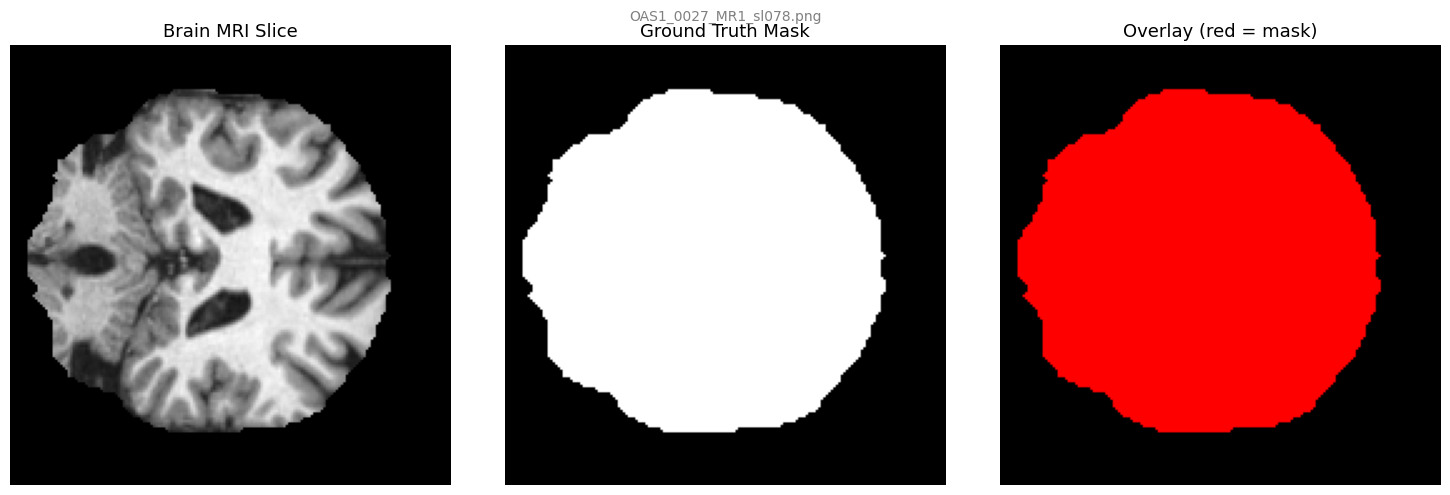

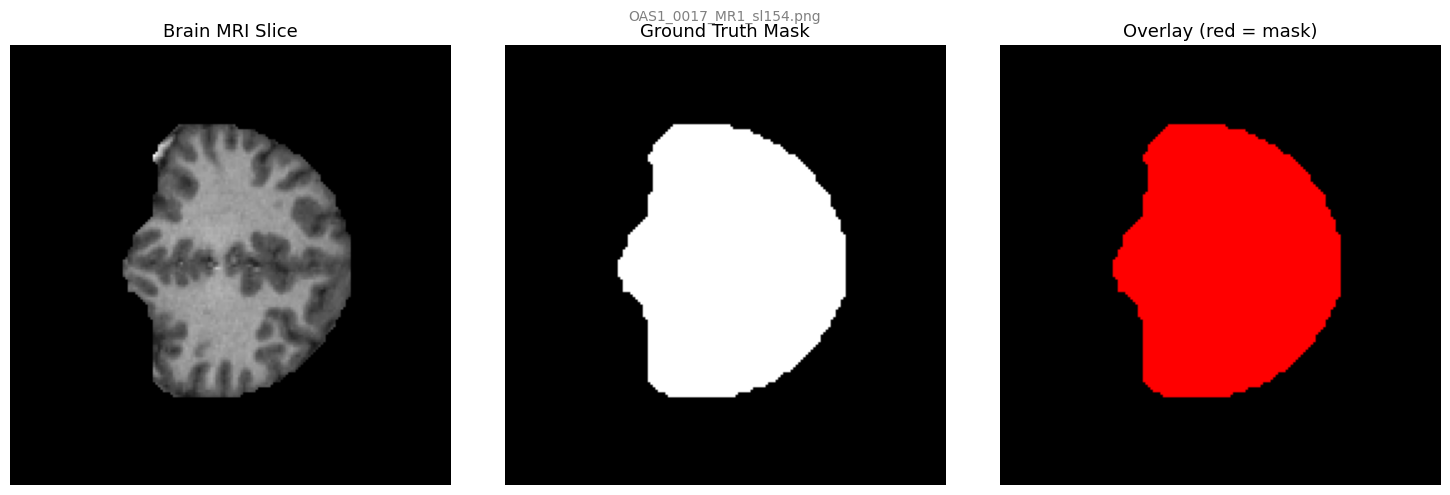

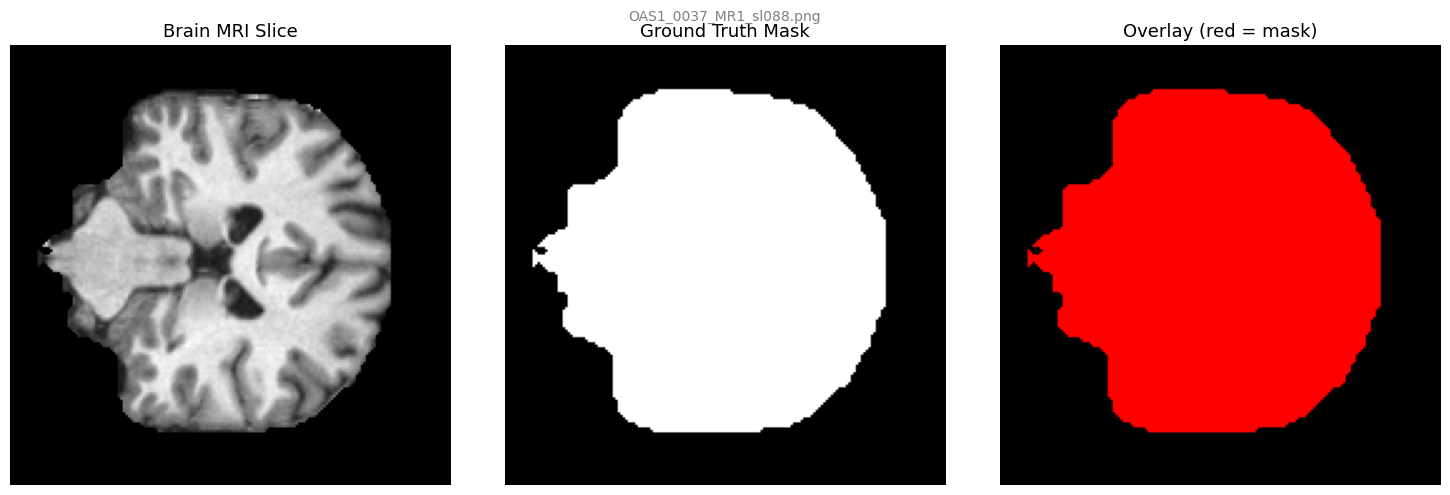

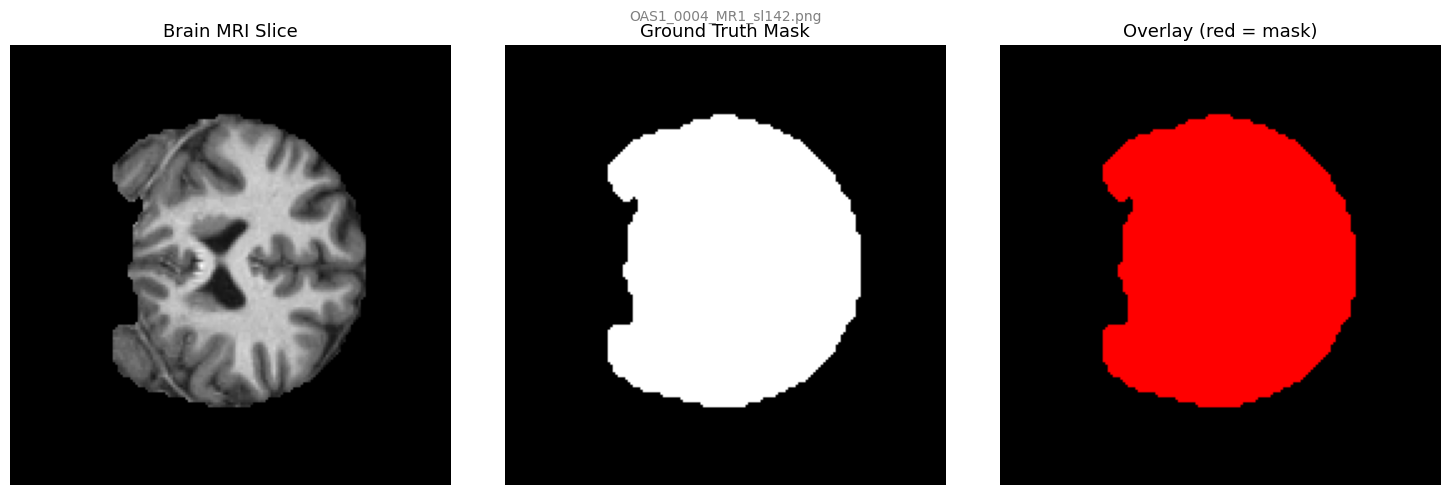

In [10]:
def visualize_sample(image_name, img_dir=IMAGE_FOLDER, mask_dir=MASK_FOLDER):
    img  = cv2.imread(os.path.join(img_dir,  image_name), cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(os.path.join(mask_dir, image_name), cv2.IMREAD_GRAYSCALE)

    overlay = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    overlay[mask > 127, 0] = 255  # red channel highlight
    overlay[mask > 127, 1] = 0
    overlay[mask > 127, 2] = 0

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img,     cmap='gray');  axes[0].set_title('Brain MRI Slice',      fontsize=13)
    axes[1].imshow(mask,    cmap='gray');  axes[1].set_title('Ground Truth Mask',    fontsize=13)
    axes[2].imshow(overlay);               axes[2].set_title('Overlay (red = mask)', fontsize=13)
    for ax in axes: ax.axis('off')
    plt.suptitle(image_name, fontsize=10, color='gray')
    plt.tight_layout()
    plt.show()


all_images = os.listdir(IMAGE_FOLDER)
for _ in range(4):
    visualize_sample(random.choice(all_images))

## 5. Train / Test Split

In [11]:
images = sorted([f for f in os.listdir(IMAGE_FOLDER) if f.endswith('.png')])
masks  = sorted([f for f in os.listdir(MASK_FOLDER)  if f.endswith('.png')])

assert images == masks, 'Image-mask mismatch! Check filenames.'

train_imgs, test_imgs = train_test_split(images, test_size=TEST_SPLIT, random_state=SEED)
print(f'Train: {len(train_imgs)}  |  Test: {len(test_imgs)}')

def copy_files(file_list, src_img, src_mask, dst_img, dst_mask):
    for f in tqdm(file_list, leave=False):
        shutil.copy(os.path.join(src_img,  f), os.path.join(dst_img,  f))
        shutil.copy(os.path.join(src_mask, f), os.path.join(dst_mask, f))

copy_files(train_imgs, IMAGE_FOLDER, MASK_FOLDER, TRAIN_IMG_DIR, TRAIN_MASK_DIR)
copy_files(test_imgs,  IMAGE_FOLDER, MASK_FOLDER, TEST_IMG_DIR,  TEST_MASK_DIR)
print('Files copied ✓')

Train: 2850  |  Test: 504


  0%|          | 0/2850 [00:00<?, ?it/s]

  0%|          | 0/504 [00:00<?, ?it/s]

Files copied ✓


## 6. tf.data Pipeline

In [12]:
def load_image(img_path, mask_path):
    # ── Image ──────────────────────────────────────────────────────────────────
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=3)   # grayscale → 3-ch for VGG16
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0

    # ── Mask ───────────────────────────────────────────────────────────────────
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, IMG_SIZE, method='nearest')
    mask = tf.cast(mask, tf.float32) / 255.0

    return img, mask


def augment(img, mask):
    """Random flip + brightness jitter (applied consistently to img; mask only flipped)"""
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)
    img = tf.image.random_brightness(img, max_delta=0.1)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, mask


def build_dataset(img_dir, mask_dir, augment_data=False, batch=BATCH_SIZE):
    img_files  = sorted([os.path.join(img_dir,  f) for f in os.listdir(img_dir)  if f.endswith('.png')])
    mask_files = sorted([os.path.join(mask_dir, f) for f in os.listdir(mask_dir) if f.endswith('.png')])

    ds = tf.data.Dataset.from_tensor_slices((img_files, mask_files))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch).prefetch(tf.data.AUTOTUNE)
    return ds


train_dataset = build_dataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, augment_data=True)
test_dataset  = build_dataset(TEST_IMG_DIR,  TEST_MASK_DIR,  augment_data=False)

print('Datasets ready ✓')
for imgs, masks in train_dataset.take(1):
    print('Batch shapes →  images:', imgs.shape, ' masks:', masks.shape)

I0000 00:00:1781252604.084215     679 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Datasets ready ✓
Batch shapes →  images: (16, 224, 224, 3)  masks: (16, 224, 224, 1)


## 7. Model — VGG16 Encoder + UNet Decoder

In [13]:
def conv_block(x, filters, name_prefix):
    """Two Conv2D + BN + ReLU layers."""
    x = Conv2D(filters, (3,3), padding='same', name=f'{name_prefix}_c1')(x)
    x = BatchNormalization(name=f'{name_prefix}_bn1')(x)
    x = Activation('relu', name=f'{name_prefix}_act1')(x)
    x = Conv2D(filters, (3,3), padding='same', name=f'{name_prefix}_c2')(x)
    x = BatchNormalization(name=f'{name_prefix}_bn2')(x)
    x = Activation('relu', name=f'{name_prefix}_act2')(x)
    return x


def decoder_block(x, skip, filters, name_prefix):
    """Upsample → concatenate skip → conv_block."""
    x = UpSampling2D((2, 2), name=f'{name_prefix}_up')(x)
    x = concatenate([x, skip], name=f'{name_prefix}_cat')
    x = Dropout(0.2, name=f'{name_prefix}_drop')(x)
    x = conv_block(x, filters, name_prefix)
    return x


def build_vgg16_unet(input_shape=(224, 224, 3), freeze_encoder=True):
    """
    VGG16 encoder (ImageNet weights) + symmetric UNet decoder.
    Skip connections taken from VGG16's block outputs.
    """
    inputs = Input(shape=input_shape, name='input')

    # ── Encoder (VGG16) ────────────────────────────────────────────────────────
    base = VGG16(include_top=False, weights='imagenet', input_tensor=inputs)

    if freeze_encoder:
        for layer in base.layers:
            layer.trainable = False

    # Skip connections at progressively deeper resolutions
    s1 = base.get_layer('block1_conv2').output   # 224×224,  64 ch
    s2 = base.get_layer('block2_conv2').output   # 112×112, 128 ch
    s3 = base.get_layer('block3_conv3').output   #  56×56,  256 ch
    s4 = base.get_layer('block4_conv3').output   #  28×28,  512 ch

    # Bottleneck
    b  = base.get_layer('block5_conv3').output   #  14×14,  512 ch

    # ── Decoder ────────────────────────────────────────────────────────────────
    d4 = decoder_block(b,  s4, 512, 'dec4')      #  28×28
    d3 = decoder_block(d4, s3, 256, 'dec3')      #  56×56
    d2 = decoder_block(d3, s2, 128, 'dec2')      # 112×112
    d1 = decoder_block(d2, s1,  64, 'dec1')      # 224×224

    # ── Output ─────────────────────────────────────────────────────────────────
    output = Conv2D(1, (1, 1), activation='sigmoid', name='output')(d1)

    model = Model(inputs=inputs, outputs=output, name='VGG16_UNet')
    return model


model = build_vgg16_unet(input_shape=(*IMG_SIZE, 3), freeze_encoder=True)
print('Model built ✓')
print(f'Total parameters      : {model.count_params():,}')
print(f'Trainable parameters  : {sum([K.count_params(w) for w in model.trainable_weights]):,}')

Model built ✓
Total parameters      : 24,898,817
Trainable parameters  : 10,180,289


## 8. Custom Metrics & Loss

In [14]:
def dice_coefficient(y_true, y_pred, smooth=1.0):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2.0 * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)


def dice_loss(y_true, y_pred):
    return 1.0 - dice_coefficient(y_true, y_pred)


def iou_score(y_true, y_pred, smooth=1.0):
    """Intersection over Union  (Jaccard Index)"""
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)


def precision_smooth(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return intersection / (K.sum(y_pred_f) + K.epsilon())


def recall_smooth(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return intersection / (K.sum(y_true_f) + K.epsilon())


def pixel_accuracy(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    tp = K.sum(K.round(K.clip(y_true_f * y_pred_f, 0, 1)))
    tn = K.sum(K.round(K.clip((1 - y_true_f) * (1 - y_pred_f), 0, 1)))
    total = K.cast(tf.size(y_true_f), K.floatx())
    return (tp + tn) / total


# Combined loss: Dice + Binary Cross-Entropy
def combined_loss(y_true, y_pred):
    return dice_loss(y_true, y_pred) + tf.keras.losses.binary_crossentropy(y_true, y_pred)


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=combined_loss,
    metrics=[dice_coefficient, iou_score, precision_smooth, recall_smooth, pixel_accuracy]
)

print('Model compiled ✓')

Model compiled ✓


## 9. Model Summary & Architecture Plot

Model: "VGG16_UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 224, 224,  │      1,792 │ input[0][0]       │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 224, 224,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 112, 112,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 112, 112,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 112, 112,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 56, 56,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 56, 56,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 56, 56,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 56, 56,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 28, 28,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 28, 28,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 28, 28,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 28, 28,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 14, 14,    │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 14, 14,    │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 14, 14,    │  2,359,808 │ block5_conv1[0][

 Total params: 24,898,817 (94.98 MB)

 Trainable params: 10,180,289 (38.83 MB)

 Non-trainable params: 14,718,528 (56.15 MB)

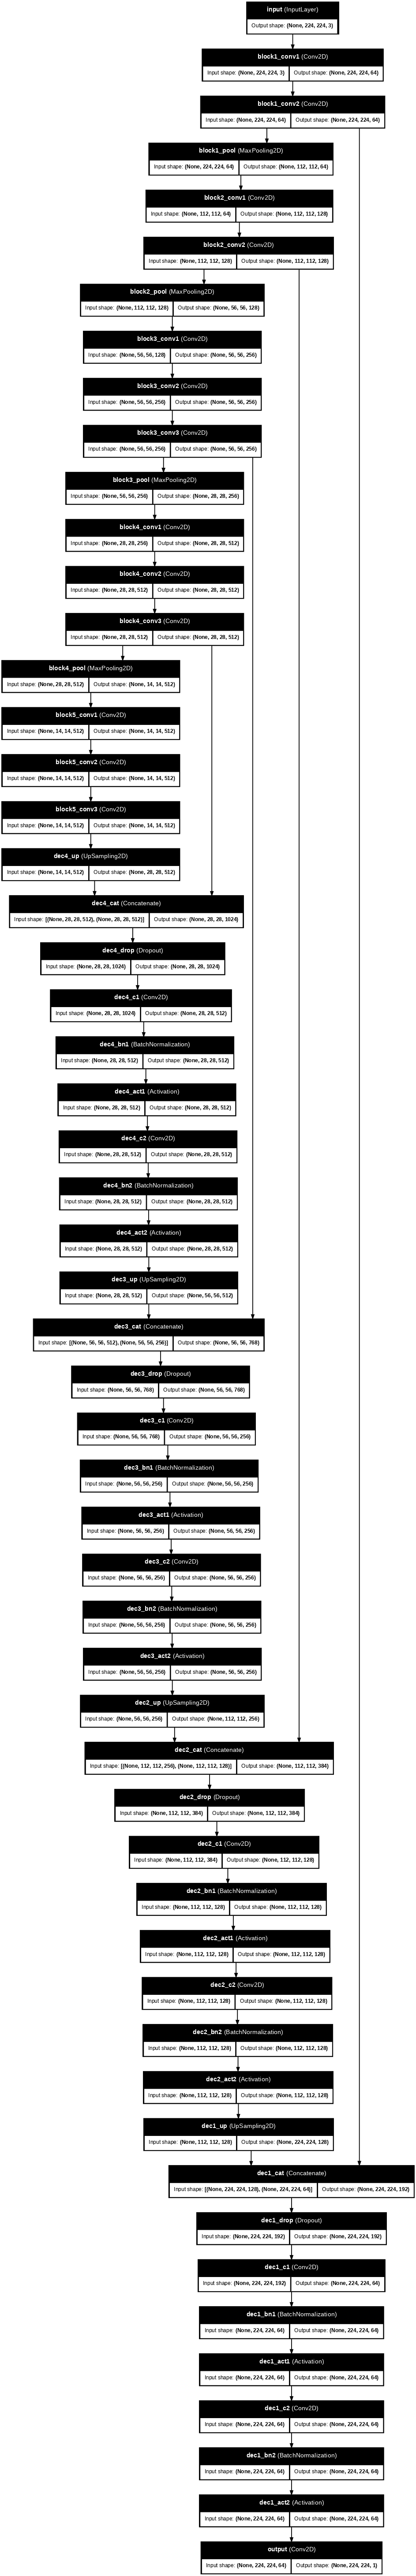

In [15]:
model.summary()

tf.keras.utils.plot_model(
    model,
    to_file='vgg16_unet_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    rankdir='TB',
    dpi=64
)

## 10. Callbacks

In [16]:
def create_mask(pred):
    return tf.math.round(pred)


def show_predictions(dataset, num=3, model_to_use=None):
    m = model_to_use or model
    for imgs, masks in dataset.take(1):
        preds = m.predict(imgs, verbose=0)
        for i in range(min(num, len(imgs))):
            pred_mask = create_mask(preds[i])
            fig, axes = plt.subplots(1, 3, figsize=(12, 4))
            axes[0].imshow(imgs[i].numpy());            axes[0].set_title('Input MRI')
            axes[1].imshow(masks[i].numpy()[..., 0], cmap='gray'); axes[1].set_title('Ground Truth')
            axes[2].imshow(pred_mask.numpy()[..., 0], cmap='gray'); axes[2].set_title('Prediction')
            for ax in axes: ax.axis('off')
            plt.tight_layout()
            plt.show()


class DisplayCallback(callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 10 == 0:
            show_predictions(test_dataset, num=2)
            print(f'Prediction after epoch {epoch + 1}\n')


logdir = os.path.join('logs', datetime.datetime.now().strftime('%Y%m%d-%H%M%S'))

callbacks_list = [
    DisplayCallback(),
    callbacks.TensorBoard(logdir, histogram_freq=1),
    callbacks.ModelCheckpoint('best_model.keras', verbose=1, save_best_only=True,
                               monitor='val_iou_score', mode='max'),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5,
                                 min_lr=1e-7, verbose=1),
    callbacks.EarlyStopping(monitor='val_iou_score', patience=15, mode='max',
                             restore_best_weights=True, verbose=1),
]

print('Callbacks ready ✓')

Callbacks ready ✓


## 11. Initial Predictions (before training)

Predictions before training:


I0000 00:00:1781252607.163149     727 service.cc:152] XLA service 0x79f95c016b80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781252607.163184     727 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1781252607.394840     727 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1781252621.003424     727 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


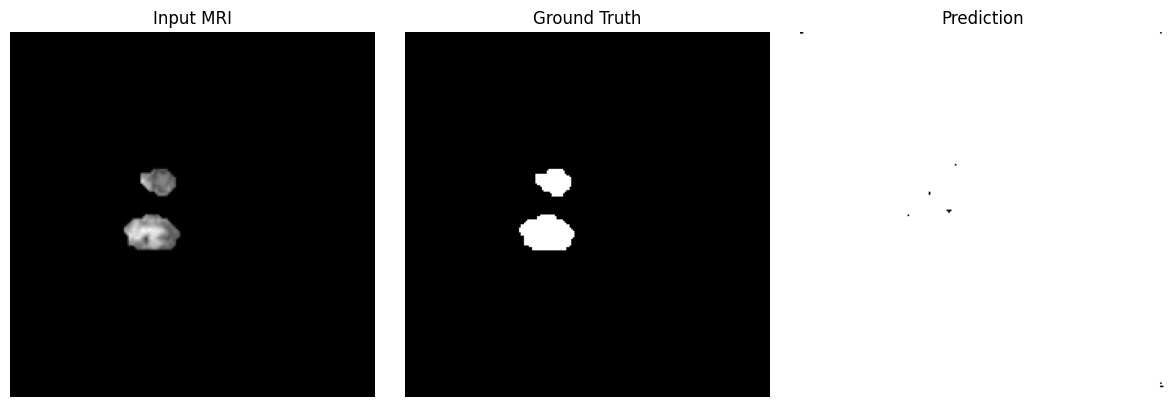

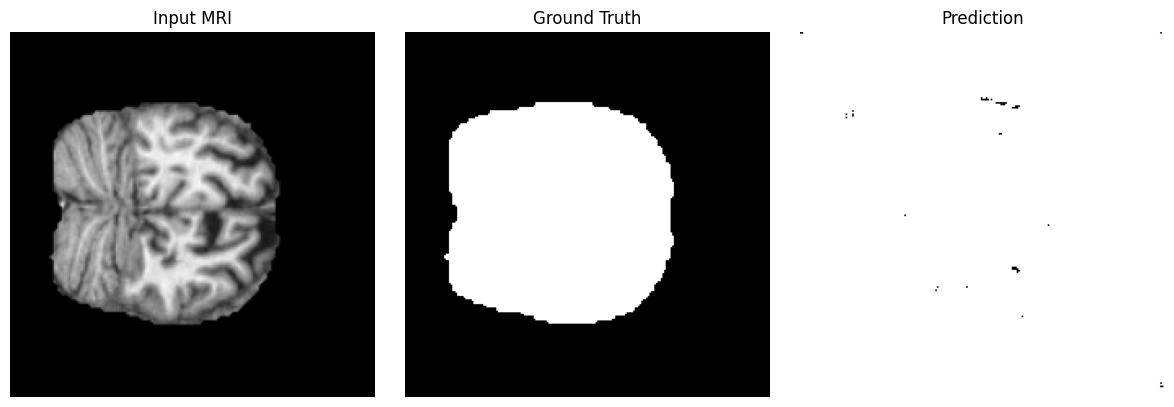

In [17]:
print('Predictions before training:')
show_predictions(test_dataset, num=2)

## 12. Training

Steps per epoch  : 178
Validation steps : 31
Epoch 1/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - dice_coefficient: 0.7717 - iou_score: 0.6660 - loss: 0.4362 - pixel_accuracy: 0.9266 - precision_smooth: 0.6922 - recall_smooth: 0.9360
Epoch 1: val_iou_score improved from None to 0.83591, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
178/178 ━━━━━━━━━━━━━━━━━━━━ 83s 308ms/step - dice_coefficient: 0.8410 - iou_score: 0.7564 - loss: 0.2699 - pixel_accuracy: 0.9772 - precision_smooth: 0.7720 - recall_smooth: 0.9737 - val_dice_coefficient: 0.9104 - val_iou_score: 0.8359 - val_loss: 0.1532 - val_pixel_accuracy: 0.9964 - val_precision_smooth: 0.8391 - val_recall_smooth: 0.9954 - learning_rate: 1.0000e-04
Epoch 2/50


2026-06-12 08:25:09.563853: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-12 08:25:09.861951: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  1/178 ━━━━━━━━━━━━━━━━━━━━ 37:22 13s/step - dice_coefficient: 0.2018 - iou_score: 0.1122 - loss: 1.1519 - pixel_accuracy: 0.9740 - precision_smooth: 0.1122 - recall_smooth: 0.9996
Epoch 2: val_iou_score did not improve from 0.83591
178/178 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - dice_coefficient: 0.2018 - iou_score: 0.1122 - loss: 1.1519 - pixel_accuracy: 0.9740 - precision_smooth: 0.1122 - recall_smooth: 0.9996 - val_dice_coefficient: 0.9089 - val_iou_score: 0.8335 - val_loss: 0.1559 - val_pixel_accuracy: 0.9964 - val_precision_smooth: 0.8365 - val_recall_smooth: 0.9957 - learning_rate: 1.0000e-04
Epoch 3/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - dice_coefficient: 0.8962 - iou_score: 0.8328 - loss: 0.1568 - pixel_accuracy: 0.9959 - precision_smooth: 0.8402 - recall_smooth: 0.9913
Epoch 3: val_iou_score improved from 0.83591 to 0.91632, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
178/178 ━━━━━━━━━━━━━━━━━━━━ 53s 295ms/step - dice_coefficien

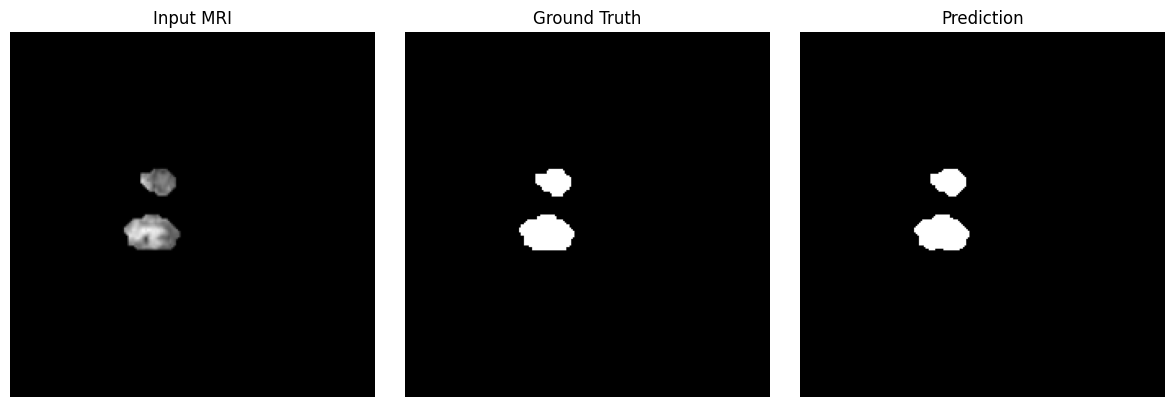

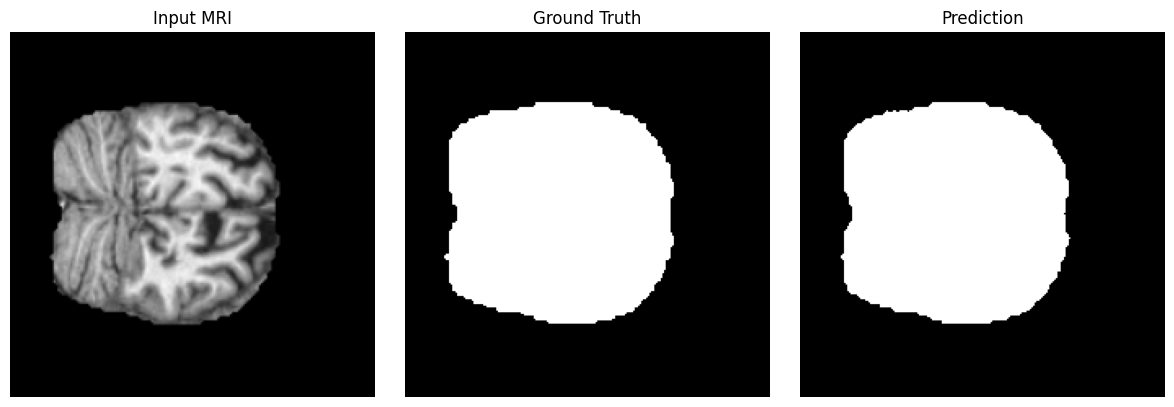

Prediction after epoch 10


Epoch 10: val_iou_score did not improve from 0.96771
178/178 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - dice_coefficient: 0.4029 - iou_score: 0.2523 - loss: 0.7168 - pixel_accuracy: 0.9953 - precision_smooth: 0.2523 - recall_smooth: 0.9993 - val_dice_coefficient: 0.9834 - val_iou_score: 0.9674 - val_loss: 0.0280 - val_pixel_accuracy: 0.9982 - val_precision_smooth: 0.9730 - val_recall_smooth: 0.9941 - learning_rate: 1.0000e-04
Epoch 11/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - dice_coefficient: 0.9580 - iou_score: 0.9246 - loss: 0.0603 - pixel_accuracy: 0.9977 - precision_smooth: 0.9298 - recall_smooth: 0.9942
Epoch 11: val_iou_score improved from 0.96771 to 0.97407, saving model to best_model.keras

Epoch 11: finished saving model to best_model.keras
178/178 ━━━━━━━━━━━━━━━━━━━━ 52s 295ms/step - dice_coefficient: 0.9577 - iou_score: 0.9242 - loss: 0.0603 - pixel_accuracy: 0.9977 - precision_smooth: 0.9294 - recall_smooth: 0.9942 - val_dice_coefficient: 0.9869

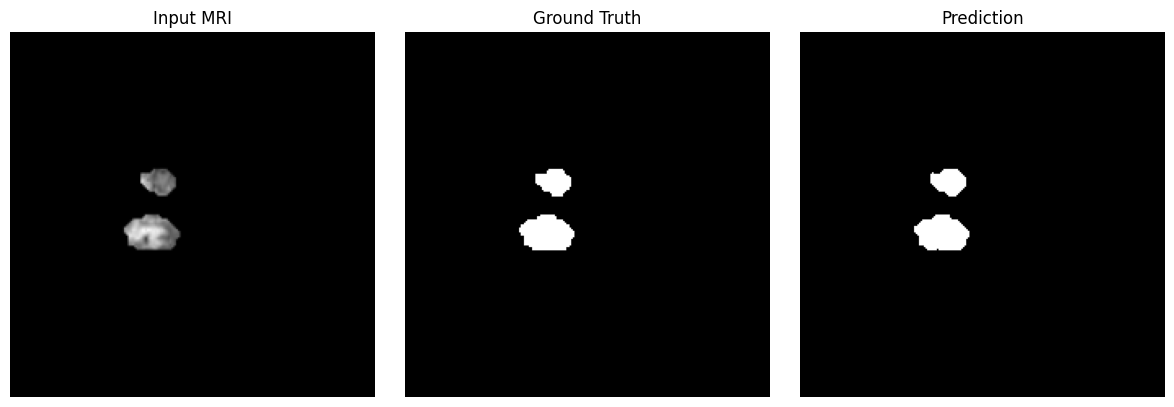

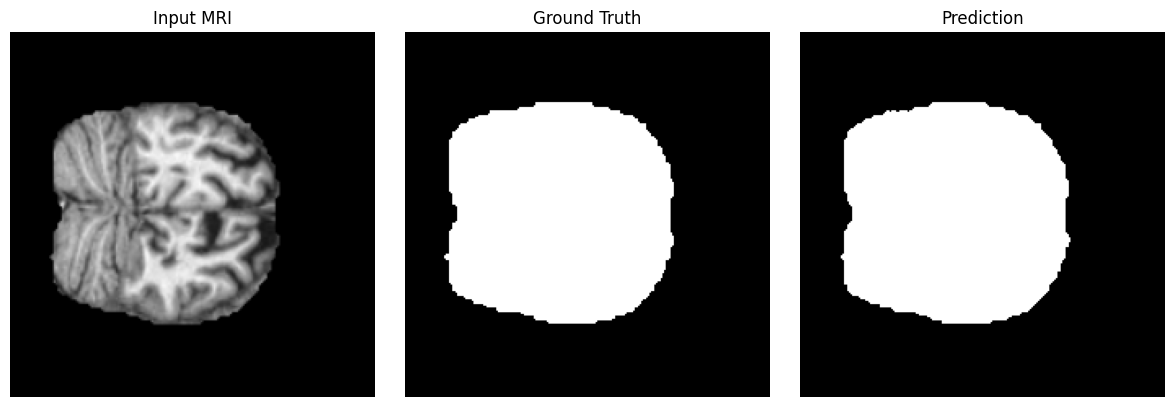

Prediction after epoch 20


Epoch 20: val_iou_score did not improve from 0.98621
178/178 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - dice_coefficient: 0.5876 - iou_score: 0.4161 - loss: 0.4647 - pixel_accuracy: 0.9990 - precision_smooth: 0.4165 - recall_smooth: 0.9970 - val_dice_coefficient: 0.9929 - val_iou_score: 0.9858 - val_loss: 0.0128 - val_pixel_accuracy: 0.9986 - val_precision_smooth: 0.9888 - val_recall_smooth: 0.9969 - learning_rate: 1.0000e-04
Epoch 21/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - dice_coefficient: 0.9802 - iou_score: 0.9626 - loss: 0.0290 - pixel_accuracy: 0.9982 - precision_smooth: 0.9666 - recall_smooth: 0.9957
Epoch 21: val_iou_score improved from 0.98621 to 0.98812, saving model to best_model.keras

Epoch 21: finished saving model to best_model.keras
178/178 ━━━━━━━━━━━━━━━━━━━━ 52s 294ms/step - dice_coefficient: 0.9797 - iou_score: 0.9615 - loss: 0.0297 - pixel_accuracy: 0.9982 - precision_smooth: 0.9657 - recall_smooth: 0.9955 - val_dice_coefficient: 0.9940

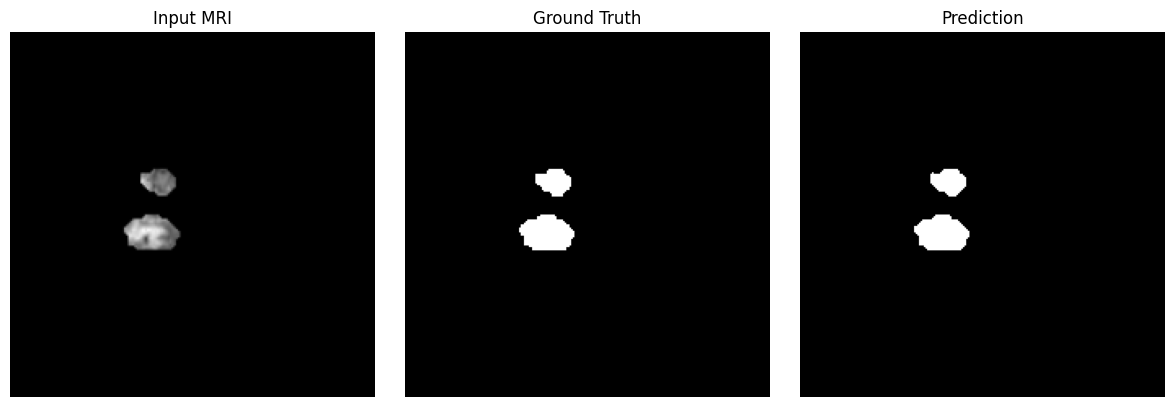

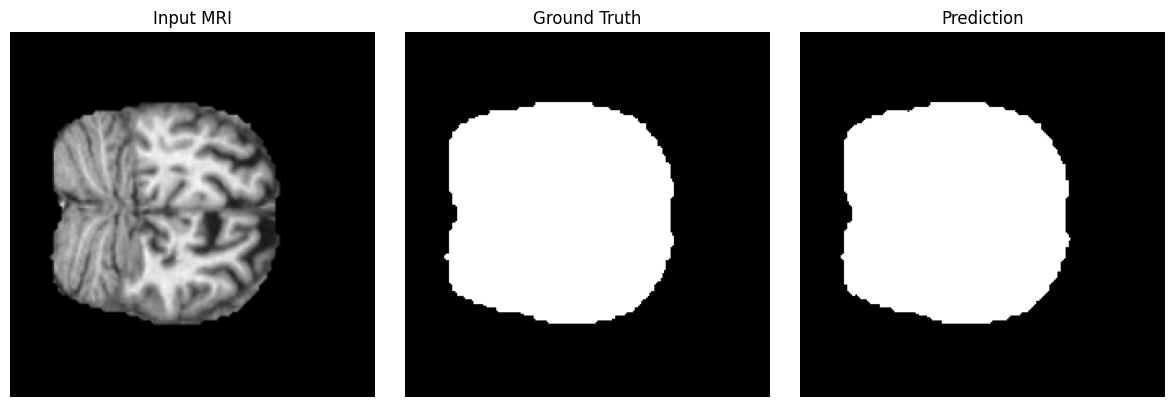

Prediction after epoch 30


Epoch 30: val_iou_score improved from 0.99181 to 0.99206, saving model to best_model.keras

Epoch 30: finished saving model to best_model.keras
178/178 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - dice_coefficient: 0.7235 - iou_score: 0.5669 - loss: 0.3055 - pixel_accuracy: 0.9989 - precision_smooth: 0.5673 - recall_smooth: 0.9984 - val_dice_coefficient: 0.9960 - val_iou_score: 0.9921 - val_loss: 0.0078 - val_pixel_accuracy: 0.9988 - val_precision_smooth: 0.9945 - val_recall_smooth: 0.9976 - learning_rate: 1.0000e-04
Epoch 31/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - dice_coefficient: 0.9885 - iou_score: 0.9777 - loss: 0.0178 - pixel_accuracy: 0.9984 - precision_smooth: 0.9814 - recall_smooth: 0.9961
Epoch 31: val_iou_score improved from 0.99206 to 0.99226, saving model to best_model.keras

Epoch 31: finished saving model to best_model.keras
178/178 ━━━━━━━━━━━━━━━━━━━━ 52s 295ms/step - dice_coefficient: 0.9882 - iou_score: 0.9771 - loss: 0.0182 - pixel_accurac

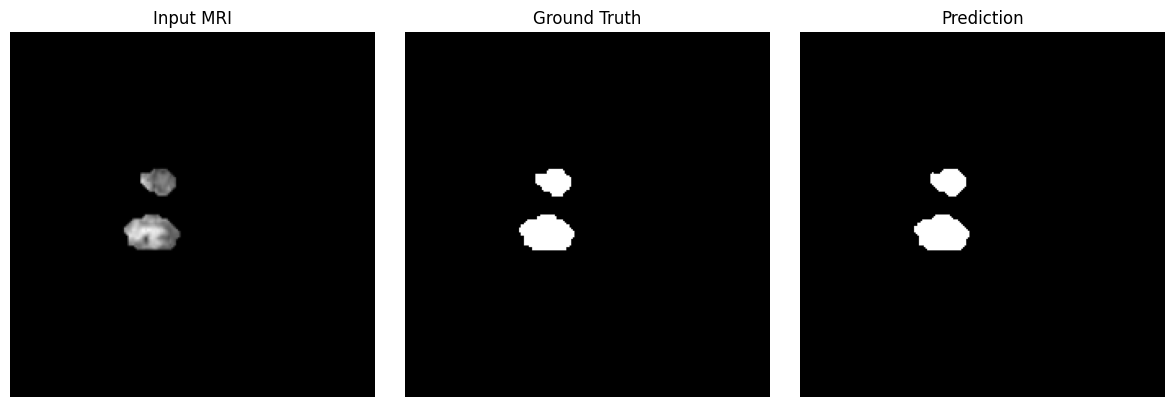

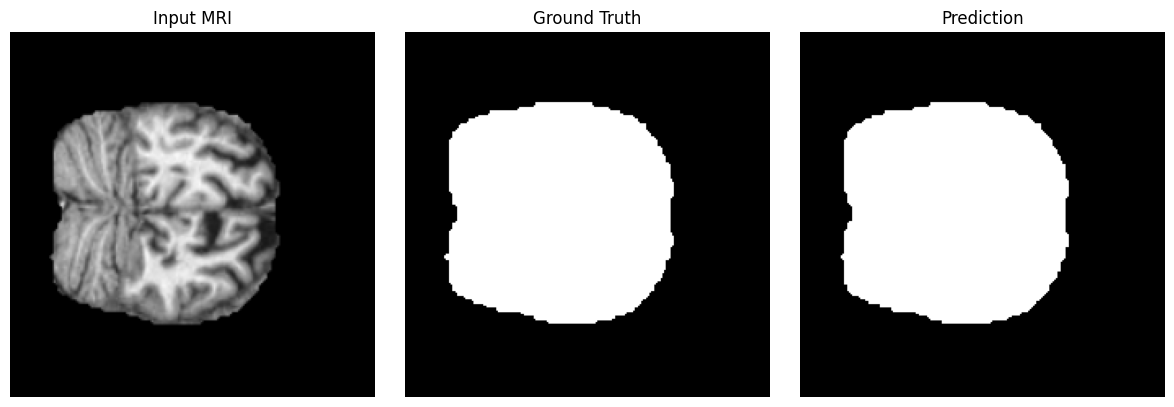

Prediction after epoch 40


Epoch 40: val_iou_score did not improve from 0.99383
178/178 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - dice_coefficient: 0.8211 - iou_score: 0.6965 - loss: 0.1963 - pixel_accuracy: 0.9991 - precision_smooth: 0.6973 - recall_smooth: 0.9981 - val_dice_coefficient: 0.9966 - val_iou_score: 0.9932 - val_loss: 0.0072 - val_pixel_accuracy: 0.9987 - val_precision_smooth: 0.9946 - val_recall_smooth: 0.9986 - learning_rate: 1.0000e-04
Epoch 41/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - dice_coefficient: 0.9926 - iou_score: 0.9855 - loss: 0.0123 - pixel_accuracy: 0.9985 - precision_smooth: 0.9889 - recall_smooth: 0.9965
Epoch 41: val_iou_score improved from 0.99383 to 0.99412, saving model to best_model.keras

Epoch 41: finished saving model to best_model.keras
178/178 ━━━━━━━━━━━━━━━━━━━━ 52s 294ms/step - dice_coefficient: 0.9923 - iou_score: 0.9849 - loss: 0.0127 - pixel_accuracy: 0.9985 - precision_smooth: 0.9884 - recall_smooth: 0.9964 - val_dice_coefficient: 0.9971

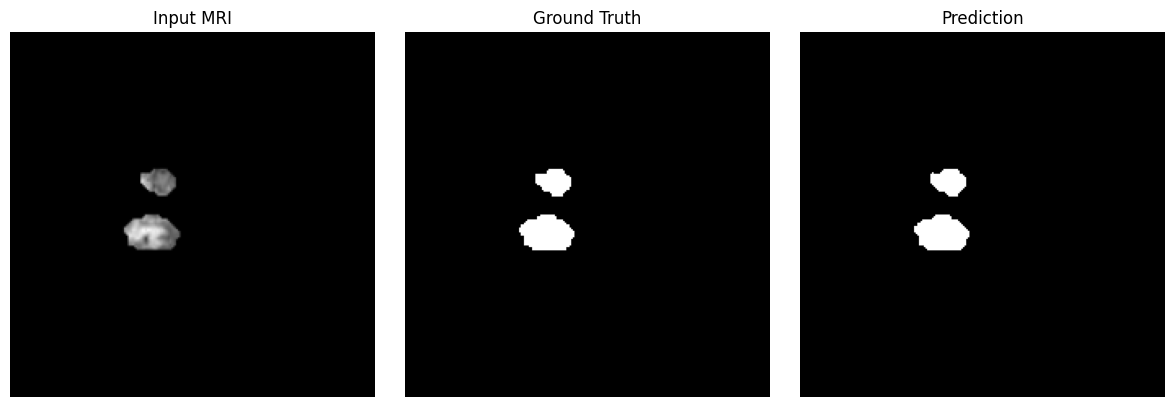

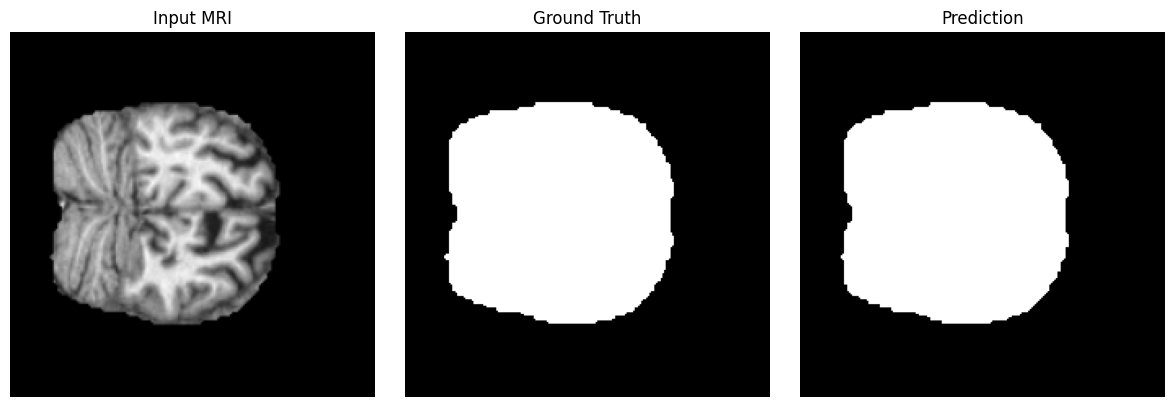

Prediction after epoch 50


Epoch 50: val_iou_score improved from 0.99490 to 0.99492, saving model to best_model.keras

Epoch 50: finished saving model to best_model.keras
178/178 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - dice_coefficient: 0.8787 - iou_score: 0.7837 - loss: 0.1318 - pixel_accuracy: 0.9995 - precision_smooth: 0.7881 - recall_smooth: 0.9928 - val_dice_coefficient: 0.9975 - val_iou_score: 0.9949 - val_loss: 0.0054 - val_pixel_accuracy: 0.9990 - val_precision_smooth: 0.9964 - val_recall_smooth: 0.9985 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 50.

Training time: 26.3 min


In [18]:
steps_per_epoch  = len(os.listdir(TRAIN_IMG_DIR)) // BATCH_SIZE
validation_steps = len(os.listdir(TEST_IMG_DIR))  // BATCH_SIZE

print(f'Steps per epoch  : {steps_per_epoch}')
print(f'Validation steps : {validation_steps}')

start_time = time.time()

history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=callbacks_list
)

elapsed = time.time() - start_time
print(f'\nTraining time: {elapsed/60:.1f} min')

## 13. Training Graphs

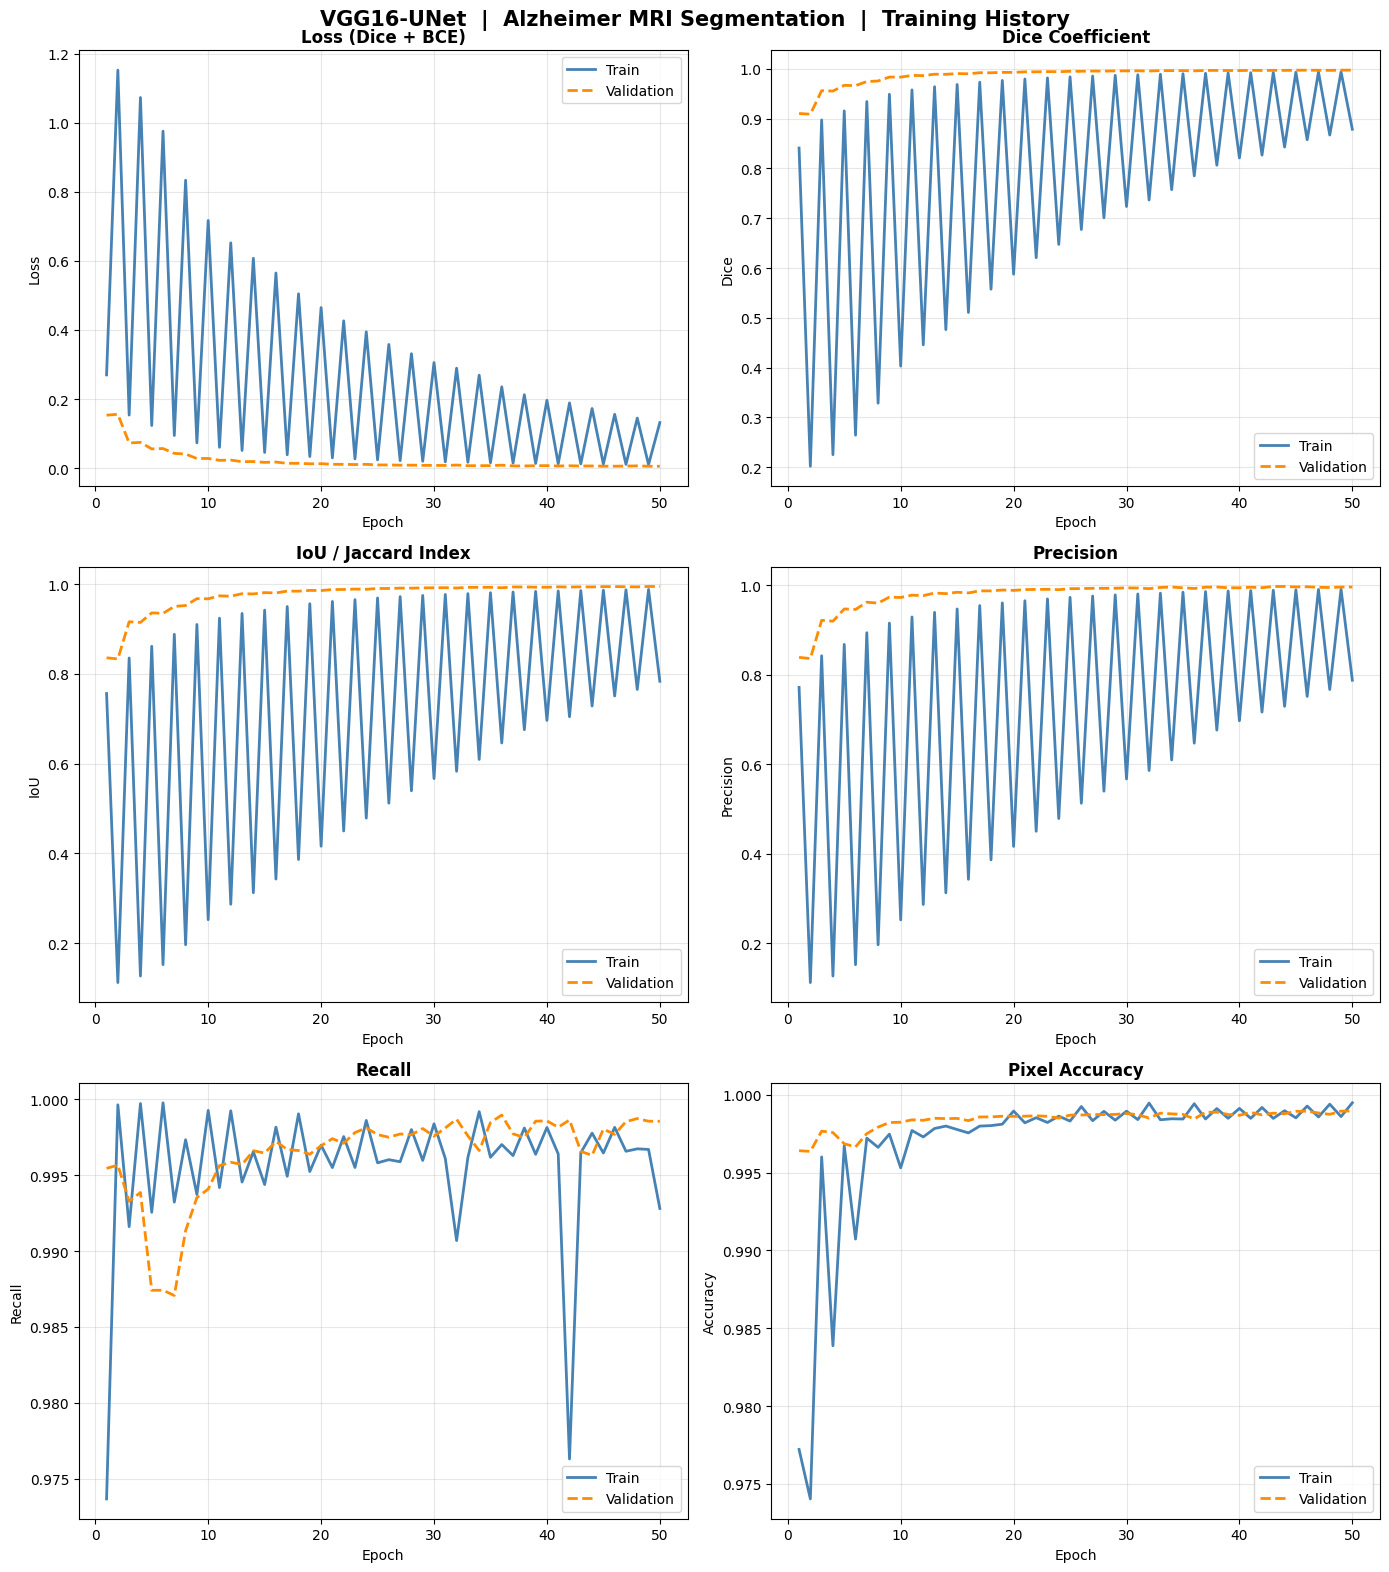

Plot saved → training_history.png


In [19]:
H = history.history

fig, axes = plt.subplots(3, 2, figsize=(14, 16))
fig.suptitle('VGG16-UNet  |  Alzheimer MRI Segmentation  |  Training History',
             fontsize=15, fontweight='bold', y=0.98)

plot_specs = [
    ('loss',             'val_loss',             'Loss (Dice + BCE)',      'Loss',     'upper right'),
    ('dice_coefficient', 'val_dice_coefficient', 'Dice Coefficient',       'Dice',     'lower right'),
    ('iou_score',        'val_iou_score',        'IoU / Jaccard Index',    'IoU',      'lower right'),
    ('precision_smooth', 'val_precision_smooth', 'Precision',              'Precision','lower right'),
    ('recall_smooth',    'val_recall_smooth',    'Recall',                 'Recall',   'lower right'),
    ('pixel_accuracy',   'val_pixel_accuracy',   'Pixel Accuracy',         'Accuracy', 'lower right'),
]

for ax, (train_key, val_key, title, ylabel, loc) in zip(axes.flatten(), plot_specs):
    epochs_range = range(1, len(H[train_key]) + 1)
    ax.plot(epochs_range, H[train_key], label='Train',      color='steelblue',   linewidth=2)
    ax.plot(epochs_range, H[val_key],   label='Validation', color='darkorange',  linewidth=2, linestyle='--')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend(loc=loc, fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved → training_history.png')

## 14. Best & Average Metrics Table

In [20]:
metric_spec = [
    ('Loss',           'loss',             'min'),
    ('Dice',           'dice_coefficient', 'max'),
    ('IoU (Jaccard)',  'iou_score',        'max'),
    ('Precision',      'precision_smooth', 'max'),
    ('Recall',         'recall_smooth',    'max'),
    ('Pixel Accuracy', 'pixel_accuracy',   'max'),
]

rows = []
for disp, key, mode in metric_spec:
    tr = np.asarray(H[key],          dtype=np.float64)
    va = np.asarray(H['val_' + key], dtype=np.float64)
    pick = np.min if mode == 'min' else np.max
    rows.append({
        'Metric':     disp,
        'Train Best': pick(tr), 'Train Avg': tr.mean(),
        'Val Best':   pick(va), 'Val Avg':   va.mean(),
    })

# F1 derived from precision & recall
def f1_curve(p, r):
    p = np.asarray(p, dtype=np.float64); r = np.asarray(r, dtype=np.float64)
    return 2.0 * p * r / (p + r + 1e-7)

tr_f1 = f1_curve(H['precision_smooth'],     H['recall_smooth'])
va_f1 = f1_curve(H['val_precision_smooth'], H['val_recall_smooth'])
rows.append({'Metric': 'F1-Score',
             'Train Best': tr_f1.max(), 'Train Avg': tr_f1.mean(),
             'Val Best':   va_f1.max(), 'Val Avg':   va_f1.mean()})

report = pd.DataFrame(rows).set_index('Metric').round(4)

print('=' * 68)
print('   BEST & AVERAGE METRICS  —  VGG16-UNet  |  OASIS Alzheimer')
print('=' * 68)
print(report.to_string())
print('=' * 68)

best_epoch_iou  = int(np.argmax(H['val_iou_score']))  + 1
best_epoch_dice = int(np.argmax(H['val_dice_coefficient'])) + 1
print(f'\nBest Val IoU : {max(H["val_iou_score"]):.4f}  (epoch {best_epoch_iou})')
print(f'Best Val Dice: {max(H["val_dice_coefficient"]):.4f}  (epoch {best_epoch_dice})')

report

   BEST & AVERAGE METRICS  —  VGG16-UNet  |  OASIS Alzheimer
                Train Best  Train Avg  Val Best  Val Avg
Metric                                                  
Loss                0.0103     0.2511    0.0054   0.0221
Dice                0.9941     0.7952    0.9975   0.9874
IoU (Jaccard)       0.9883     0.7143    0.9949   0.9758
Precision           0.9915     0.7174    0.9976   0.9792
Recall              0.9998     0.9956    0.9990   0.9964
Pixel Accuracy      0.9995     0.9969    0.9990   0.9984
F1-Score            0.9941     0.7966    0.9975   0.9874

Best Val IoU : 0.9949  (epoch 50)
Best Val Dice: 0.9975  (epoch 50)


,Train Best,Train Avg,Val Best,Val Avg
Metric,,,,
Loss,0.0103,0.2511,0.0054,0.0221
Dice,0.9941,0.7952,0.9975,0.9874
IoU (Jaccard),0.9883,0.7143,0.9949,0.9758
Precision,0.9915,0.7174,0.9976,0.9792
Recall,0.9998,0.9956,0.9990,0.9964
Pixel Accuracy,0.9995,0.9969,0.9990,0.9984
F1-Score,0.9941,0.7966,0.9975,0.9874


## 15. Load Best Model & Final Evaluation

In [21]:
best_model = tf.keras.models.load_model(
    'best_model.keras',
    custom_objects={
        'combined_loss':   combined_loss,
        'dice_coefficient': dice_coefficient,
        'iou_score':        iou_score,
        'precision_smooth': precision_smooth,
        'recall_smooth':    recall_smooth,
        'pixel_accuracy':   pixel_accuracy,
    }
)
print('Best model loaded ✓')
best_model.summary()

Best model loaded ✓


Model: "VGG16_UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 224, 224,  │      1,792 │ input[0][0]       │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 224, 224,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 112, 112,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 112, 112,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 112, 112,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 56, 56,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 56, 56,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 56, 56,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 56, 56,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 28, 28,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 28, 28,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 28, 28,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 28, 28,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 14, 14,    │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 14, 14,    │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 14, 14,    │  2,359,808 │ block5_conv1[0][

 Total params: 45,259,397 (172.65 MB)

 Trainable params: 10,180,289 (38.83 MB)

 Non-trainable params: 14,718,528 (56.15 MB)

 Optimizer params: 20,360,580 (77.67 MB)

In [22]:
print('Evaluating best model on held-out test set...\n')
test_results = best_model.evaluate(test_dataset, verbose=1)
test_dict    = dict(zip(best_model.metrics_names, test_results))

label_map = {
    'loss': 'Loss', 'dice_coefficient': 'Dice', 'iou_score': 'IoU (Jaccard)',
    'precision_smooth': 'Precision', 'recall_smooth': 'Recall', 'pixel_accuracy': 'Pixel Accuracy'
}

P = test_dict.get('precision_smooth', 0)
R = test_dict.get('recall_smooth',    0)
f1 = 2 * P * R / (P + R + 1e-7)

print('\n' + '=' * 60)
print('  FINAL TEST-SET METRICS  (VGG16-UNet | OASIS)')
print('=' * 60)
for k, v in test_dict.items():
    print(f'  {label_map.get(k, k):20s}: {v:.4f}')
print(f'  {"F1-Score":20s}: {f1:.4f}')
print('=' * 60)

final_df = pd.DataFrame([{
    'Model':      'VGG16-UNet (OASIS)',
    'IoU':        round(test_dict.get('iou_score', float('nan')), 4),
    'Dice':       round(test_dict.get('dice_coefficient', float('nan')), 4),
    'Precision':  round(P, 4),
    'Recall':     round(R, 4),
    'Accuracy':   round(test_dict.get('pixel_accuracy', float('nan')), 4),
    'F1':         round(f1, 4),
}]).set_index('Model')
final_df

Evaluating best model on held-out test set...

32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 352ms/step - dice_coefficient: 0.9974 - iou_score: 0.9949 - loss: 0.0054 - pixel_accuracy: 0.9989 - precision_smooth: 0.9963 - recall_smooth: 0.9986

  FINAL TEST-SET METRICS  (VGG16-UNet | OASIS)
  Loss                : 0.0054
  compile_metrics     : 0.9974
  F1-Score            : 0.0000


,IoU,Dice,Precision,Recall,Accuracy,F1
Model,,,,,,
VGG16-UNet (OASIS),NaN,NaN,0,0,NaN,0.0


## 16. Test Predictions Visualization

Test set predictions:


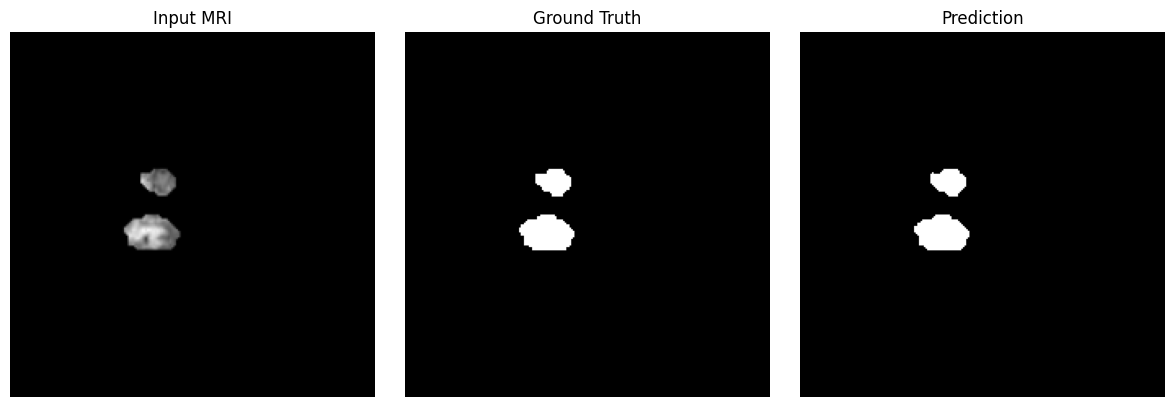

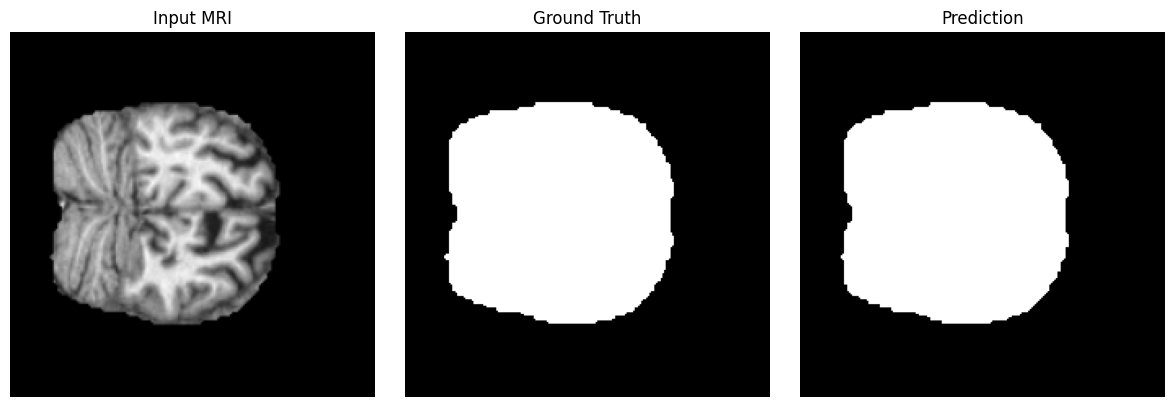

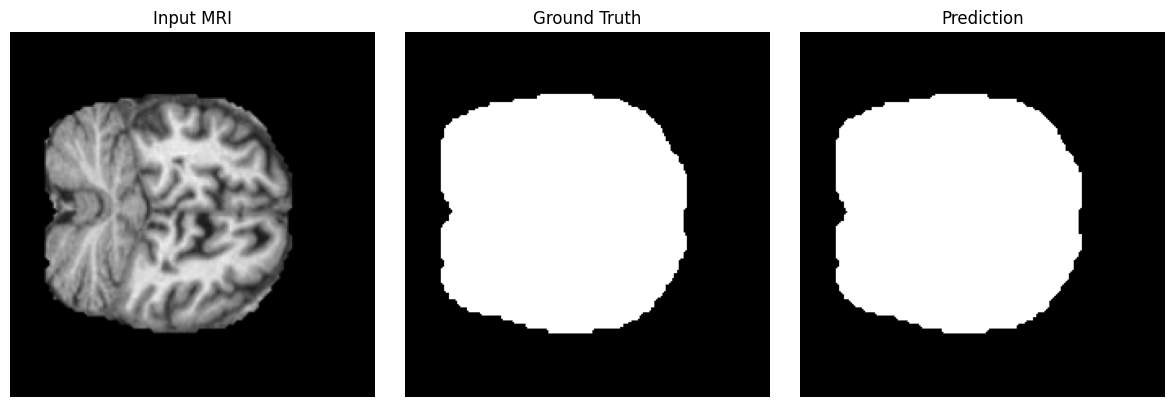

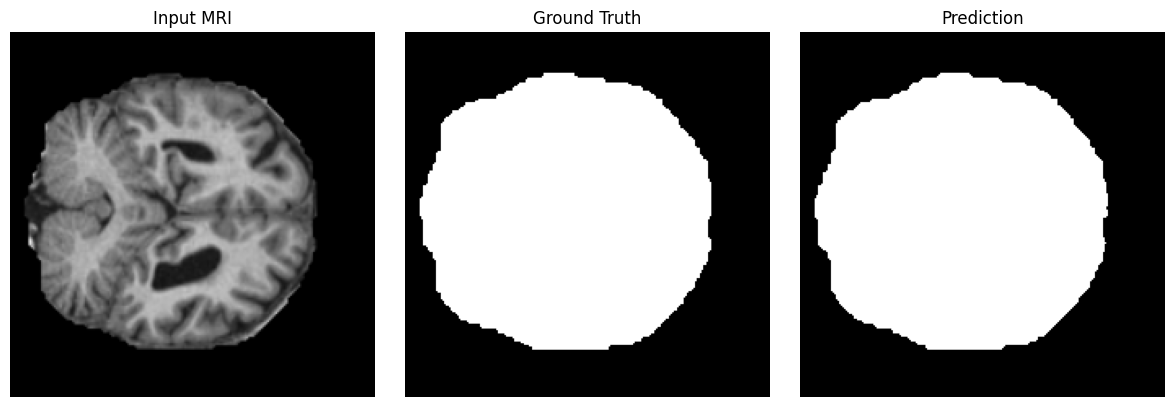

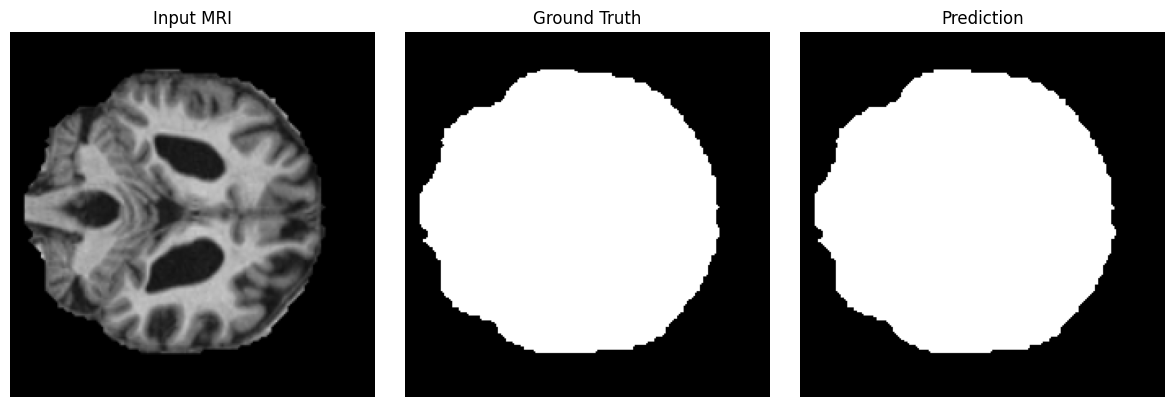

In [23]:
print('Test set predictions:')
show_predictions(test_dataset, num=5, model_to_use=best_model)

## 17. Detailed Prediction Grid

2026-06-12 08:50:22.295125: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-12 08:50:22.591402: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


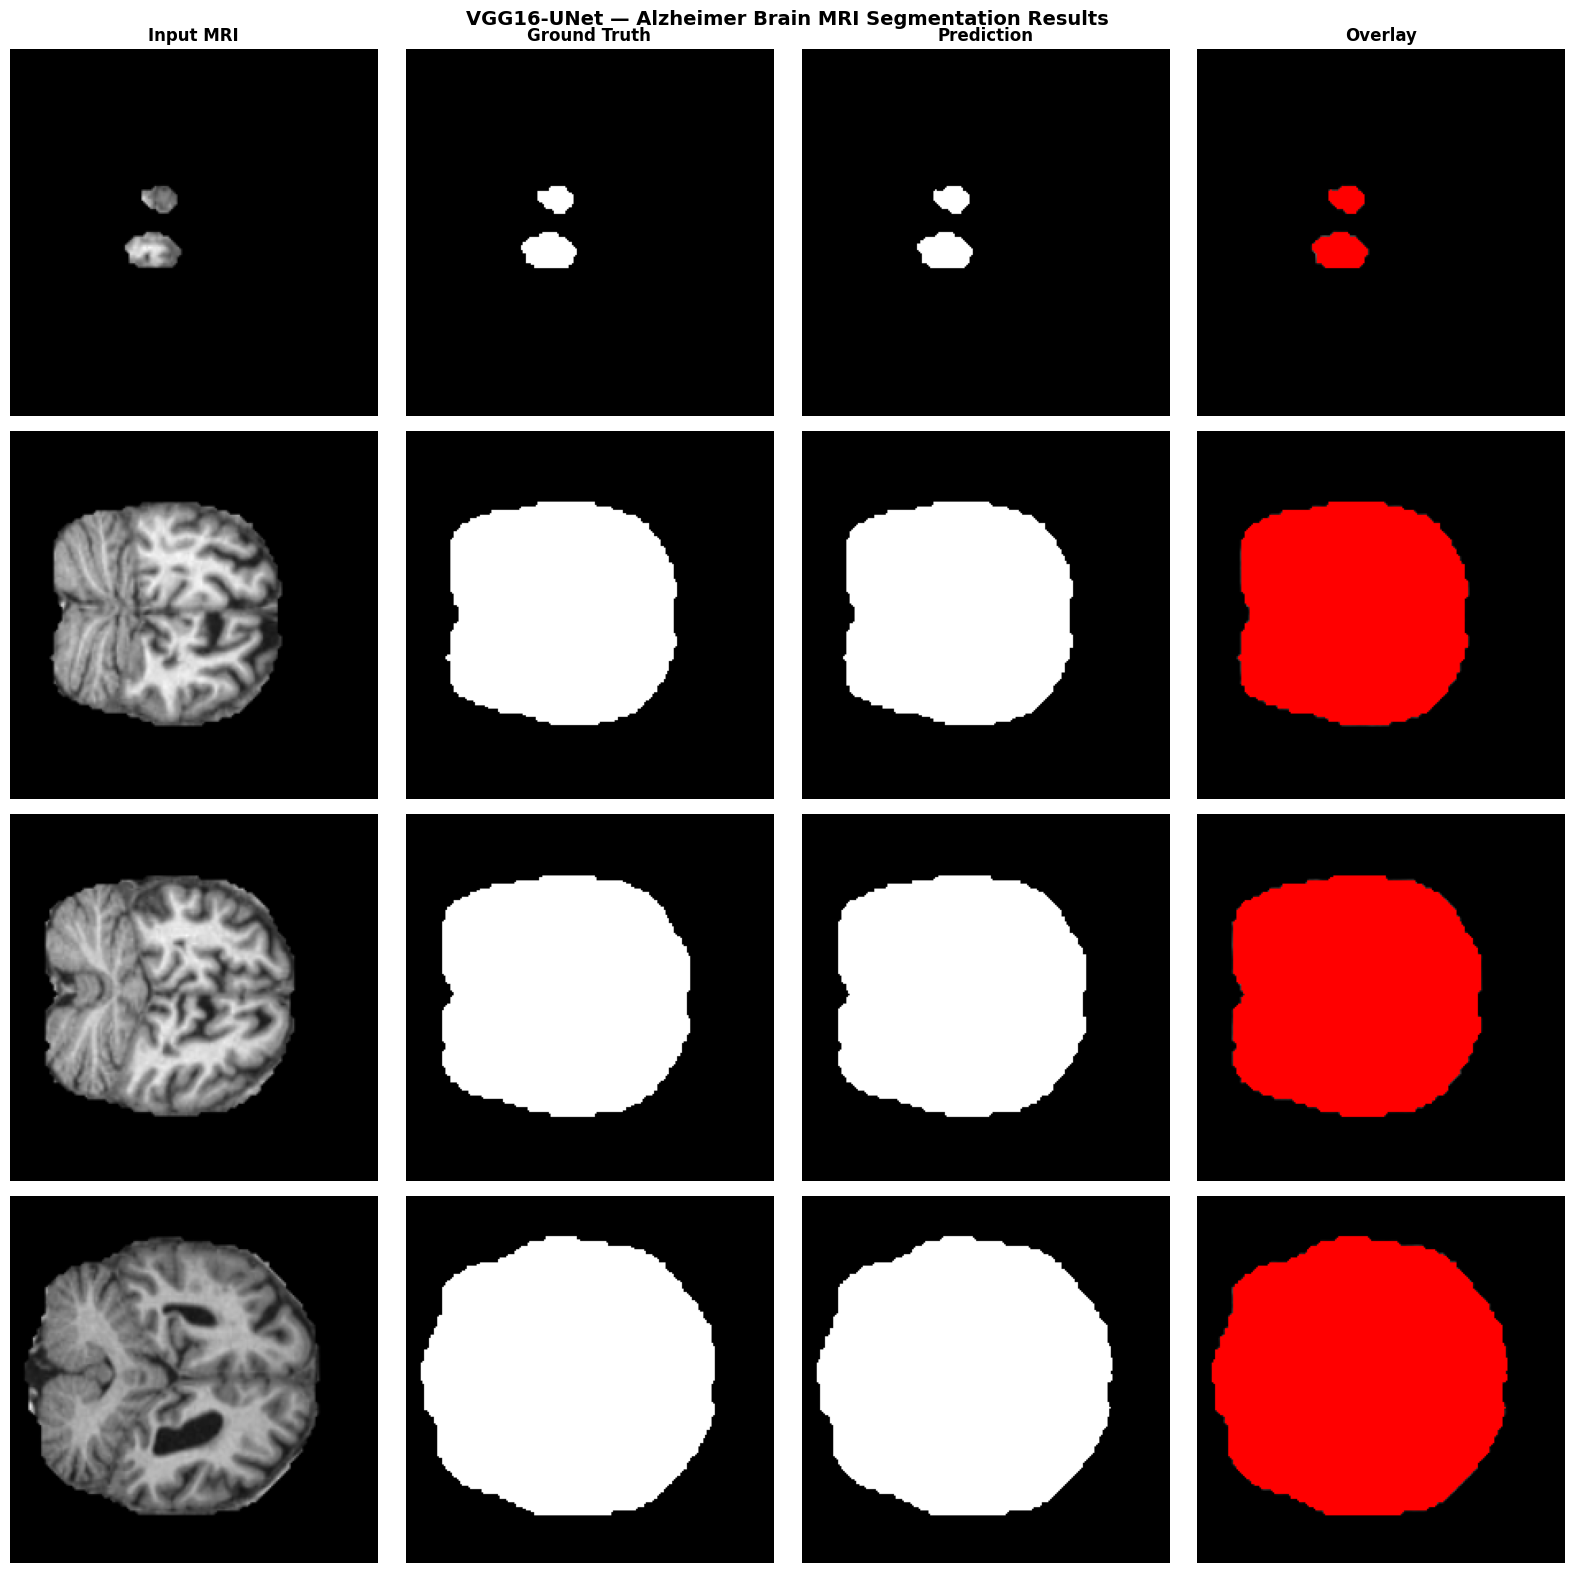

Grid saved → prediction_grid.png


In [24]:
def prediction_grid(dataset, best_model, n_rows=4):
    """Grid: Input | Ground Truth | Prediction | Overlay  ×  n_rows"""
    for imgs, masks in dataset.take(1):
        preds = best_model.predict(imgs[:n_rows], verbose=0)

        fig, axes = plt.subplots(n_rows, 4, figsize=(16, 4 * n_rows))
        col_titles = ['Input MRI', 'Ground Truth', 'Prediction', 'Overlay']
        for col, t in enumerate(col_titles):
            axes[0, col].set_title(t, fontsize=12, fontweight='bold')

        for row in range(n_rows):
            img   = imgs[row].numpy()
            gt    = masks[row].numpy()[..., 0]
            pred  = create_mask(preds[row]).numpy()[..., 0]

            # Overlay
            ov = (img * 255).astype(np.uint8)
            ov[pred > 0.5, 0] = 255
            ov[pred > 0.5, 1] = 0
            ov[pred > 0.5, 2] = 0

            # Per-sample IoU
            inter = np.sum(gt * pred)
            union = np.sum(gt) + np.sum(pred) - inter
            sample_iou = (inter + 1) / (union + 1)

            axes[row, 0].imshow(img)
            axes[row, 1].imshow(gt,   cmap='gray')
            axes[row, 2].imshow(pred, cmap='gray')
            axes[row, 2].set_xlabel(f'IoU: {sample_iou:.3f}', fontsize=10, color='green')
            axes[row, 3].imshow(ov)

            for col in range(4):
                axes[row, col].axis('off')

        plt.suptitle('VGG16-UNet — Alzheimer Brain MRI Segmentation Results',
                     fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig('prediction_grid.png', dpi=150, bbox_inches='tight')
        plt.show()
        print('Grid saved → prediction_grid.png')


prediction_grid(test_dataset, best_model, n_rows=4)

## 18. IoU Distribution Plot

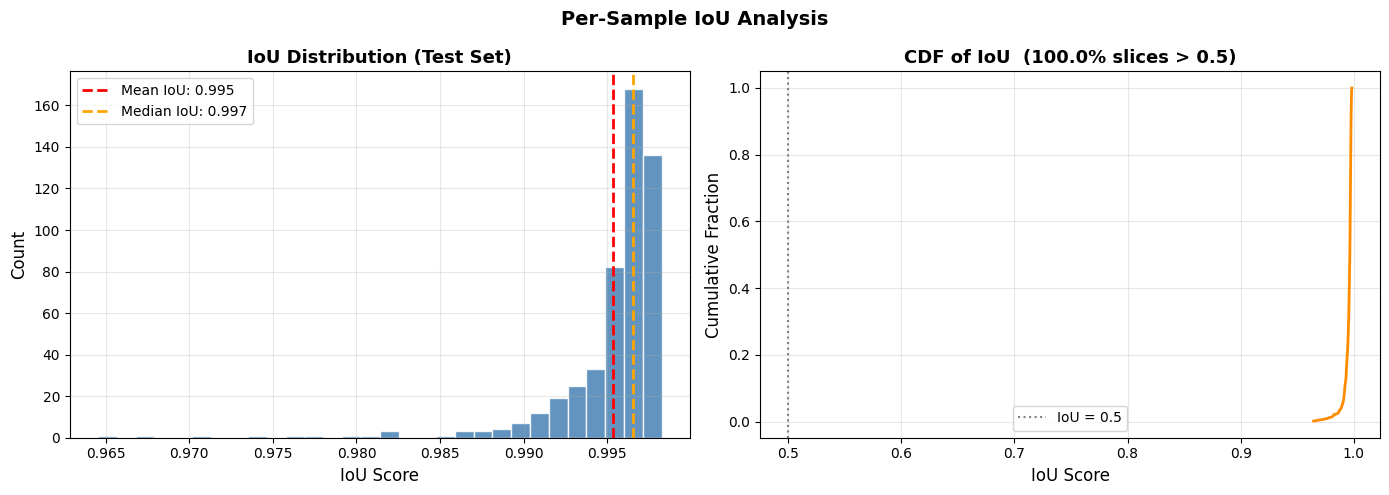


IoU Stats — Mean: 0.9953  |  Std: 0.0037
             Min : 0.9645  |  Max: 0.9983
% slices IoU > 0.5 : 100.0%


In [25]:
iou_scores = []

for imgs, masks in test_dataset:
    preds = best_model.predict(imgs, verbose=0)
    for i in range(len(imgs)):
        gt   = masks[i].numpy()[..., 0]
        pred = (preds[i][..., 0] > 0.5).astype(float)
        inter = np.sum(gt * pred)
        union = np.sum(gt) + np.sum(pred) - inter
        iou_scores.append((inter + 1) / (union + 1))

iou_arr = np.array(iou_scores)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(iou_arr, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(iou_arr.mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean IoU: {iou_arr.mean():.3f}')
axes[0].axvline(np.median(iou_arr), color='orange', linestyle='--', linewidth=2,
                label=f'Median IoU: {np.median(iou_arr):.3f}')
axes[0].set_xlabel('IoU Score', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('IoU Distribution (Test Set)', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# CDF
sorted_iou = np.sort(iou_arr)
cdf = np.arange(1, len(sorted_iou) + 1) / len(sorted_iou)
axes[1].plot(sorted_iou, cdf, color='darkorange', linewidth=2)
axes[1].axvline(0.5, color='gray', linestyle=':', label='IoU = 0.5')
pct_above_50 = np.mean(iou_arr > 0.5) * 100
axes[1].set_xlabel('IoU Score', fontsize=12)
axes[1].set_ylabel('Cumulative Fraction', fontsize=12)
axes[1].set_title(f'CDF of IoU  ({pct_above_50:.1f}% slices > 0.5)', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Per-Sample IoU Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('iou_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nIoU Stats — Mean: {iou_arr.mean():.4f}  |  Std: {iou_arr.std():.4f}')
print(f'             Min : {iou_arr.min():.4f}  |  Max: {iou_arr.max():.4f}')
print(f'% slices IoU > 0.5 : {pct_above_50:.1f}%')

## 19. Fine-tuning (Optional — unfreeze encoder)

In [26]:
# ─── Unfreeze top VGG16 blocks for fine-tuning ────────────────────────────────
# Run this cell ONLY after initial training has converged.

for layer in best_model.layers:
    if layer.name.startswith('block4') or layer.name.startswith('block5'):
        layer.trainable = True

best_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),   # lower LR
    loss=combined_loss,
    metrics=[dice_coefficient, iou_score, precision_smooth, recall_smooth, pixel_accuracy]
)

print('Fine-tuning enabled — trainable params:',
      sum([K.count_params(w) for w in best_model.trainable_weights]))

ft_callbacks = [
    callbacks.ModelCheckpoint('best_model_finetuned.keras', save_best_only=True,
                               monitor='val_iou_score', mode='max', verbose=1),
    callbacks.EarlyStopping(monitor='val_iou_score', patience=10, mode='max',
                             restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5,
                                 min_lr=1e-8, verbose=1),
]

history_ft = best_model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=20,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=ft_callbacks
)

Fine-tuning enabled — trainable params: 23159489
Epoch 1/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step - dice_coefficient: 0.9947 - iou_score: 0.9896 - loss: 0.0092 - pixel_accuracy: 0.9987 - precision_smooth: 0.9925 - recall_smooth: 0.9970
Epoch 1: val_iou_score improved from None to 0.99487, saving model to best_model_finetuned.keras

Epoch 1: finished saving model to best_model_finetuned.keras
178/178 ━━━━━━━━━━━━━━━━━━━━ 75s 321ms/step - dice_coefficient: 0.9944 - iou_score: 0.9890 - loss: 0.0097 - pixel_accuracy: 0.9987 - precision_smooth: 0.9920 - recall_smooth: 0.9969 - val_dice_coefficient: 0.9974 - val_iou_score: 0.9949 - val_loss: 0.0055 - val_pixel_accuracy: 0.9989 - val_precision_smooth: 0.9963 - val_recall_smooth: 0.9985 - learning_rate: 1.0000e-05
Epoch 2/20
  1/178 ━━━━━━━━━━━━━━━━━━━━ 26:33 9s/step - dice_coefficient: 0.8828 - iou_score: 0.7903 - loss: 0.1275 - pixel_accuracy: 0.9995 - precision_smooth: 0.7921 - recall_smooth: 0.9969
Epoch 2: val_iou_score improved from

## 20. Save Final Model

In [27]:
best_model.save('alzheimer_vgg16_unet_final.keras')
print('Model saved → alzheimer_vgg16_unet_final.keras')

Model saved → alzheimer_vgg16_unet_final.keras
